# Pixel inspector

A picture is a grid of numbers: each pixel is three values, red, green, and
blue, each 0-255. Everything below works directly on that grid -- a numpy
array of shape `(height, width, 3)` -- with no wrapper classes in between.


## Section 1 - Pull in necessary libraries 

Before you begin running the code, please open the files on the right hand side and explore what is contained in them.

When working with this program, make sure you run the cells in order from top to bottom. Otherwise you may get errors.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from piclab import io_utils, transforms, fast_transforms, encoding

#Specific to Jupyter Notebooks to have all the graphs shown embedded into this page instead of popping up on a new screen.
%matplotlib inline

## Section 2 - Load an image

This gives you back a plain numpy array. `pixels.shape` is
`(height, width, 3)` -- The values are printed using line 10 of the code and displayed below the code. The image is displayed below the information.

shape: (480, 640, 3)


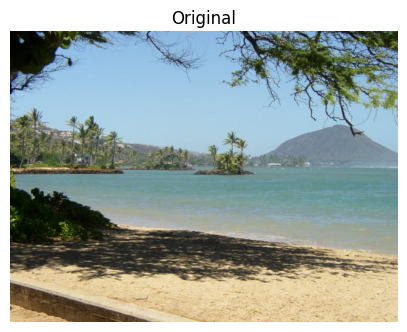

In [ ]:
from pathlib import Path

# works whether the notebook's working directory is the repo root
# (VS Code / Codespaces default) or the notebooks/ folder itself
image_path = Path("images/beach.jpg")
if not image_path.exists():
    image_path = Path("../images/beach.jpg")

pixels = io_utils.load_image(image_path)
print("shape:", pixels.shape)

plt.figure(figsize=(5, 4))
plt.imshow(pixels)
plt.axis("off")
plt.title("Original")
plt.show()

## Section 3 - A single pixel, as numbers

Pick any row/col and look at what's actually stored there.

In [ ]:
row, col = 1, 40
rgb = transforms.get_pixel(pixels, row, col)
print("RGB:   ", rgb)
print("hex:   ", encoding.to_hex(rgb))
print("binary:", encoding.to_binary(rgb))

RGB:    (9, 12, 17)
hex:    #090C11
binary: 00001001 00001100 00010001


## Section 4 - Pixel grid inspector (interactive)

Choose a small region of the image. Instead of seeing it as a photo, you'll
see it as what it actually is: a grid of colored cells, each labeled with its
own R, G, B values. Drag the red/green/blue sliders and watch the selected
region (and the full picture) update live -- same array, same numbers,
different view.

In [ ]:
region_size = 20

def show_inspector(row0, col0, red_delta, green_delta, blue_delta):
    edited = pixels.copy()
    region = edited[row0:row0 + region_size, col0:col0 + region_size].astype(int)

    ##Expanded Code
    red_colors = region[:,:,0]
    #np.clip makes it so the values in the np array of the first parameter can not be below 0 or above 255
    edited_red_colors = np.clip(red_colors + red_delta, 0, 255)
    region[:, :, 0] = edited_red_colors

    ##Condensed code for green and blue
    region[:, :, 1] = np.clip(region[:, :, 1] + green_delta, 0, 255)
    region[:, :, 2] = np.clip(region[:, :, 2] + blue_delta, 0, 255)
    edited[row0:row0 + region_size, col0:col0 + region_size] = region.astype(np.uint8)

    fig, (ax_full, ax_grid) = plt.subplots(1, 2, figsize=(10, 4.5))

    ax_full.imshow(edited)
    ax_full.add_patch(plt.Rectangle((col0, row0), region_size, region_size,
                                     fill=False, edgecolor="yellow", linewidth=2))
    ax_full.set_title("Full image")
    ax_full.axis("off")

    grid = edited[row0:row0 + region_size, col0:col0 + region_size]
    ax_grid.imshow(grid, interpolation="nearest")
    for r in range(region_size):
        for c in range(region_size):
            rr, gg, bb = grid[r, c]
            text_color = "white" if int(rr) + int(gg) + int(bb) < 380 else "black"
            ax_grid.text(c, r, f"{rr}\n{gg}\n{bb}", ha="center", va="center",
                         fontsize=6, color=text_color)
    ax_grid.set_title(f"Zoomed region ({region_size}x{region_size} pixels)")
    ax_grid.set_xticks([]); ax_grid.set_yticks([])

    plt.tight_layout()
    plt.show()

interact(
    show_inspector,
    row0=widgets.IntSlider(min=0, max=max(pixels.shape[0] - region_size, 1), step=1, value=40),
    col0=widgets.IntSlider(min=0, max=max(pixels.shape[1] - region_size, 1), step=1, value=60),
    red_delta=widgets.IntSlider(min=-255, max=255, step=1, value=0),
    green_delta=widgets.IntSlider(min=-255, max=255, step=1, value=0),
    blue_delta=widgets.IntSlider(min=-255, max=255, step=1, value=0),
);

interactive(children=(IntSlider(value=40, description='row0', max=460), IntSlider(value=60, description='col0'…

## Section 5 - Filters - Removing a Color

Here we will be exploring what an image filter is by removing a color from every pixel in our image.

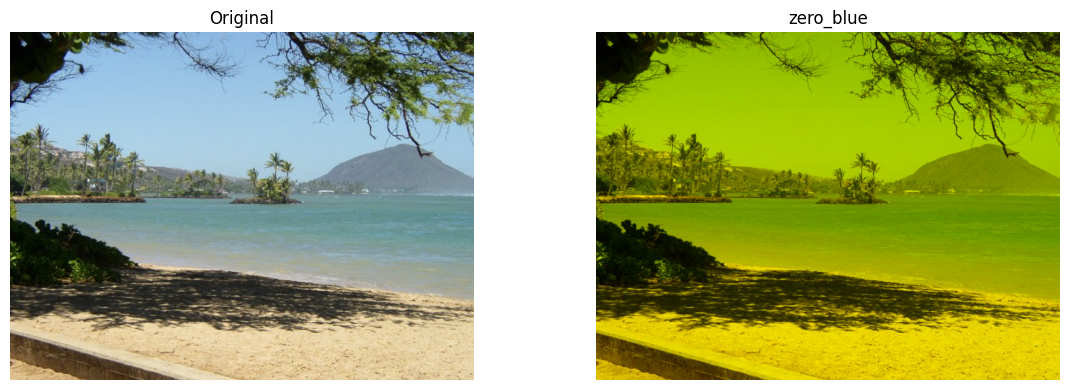

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(transforms.zero_blue(pixels)); axes[1].set_title("zero_blue"); axes[1].axis("off")
plt.tight_layout()
plt.show()

Create your own with no red and no green filters for the image

AttributeError: module 'piclab.transforms' has no attribute 'zero_red'

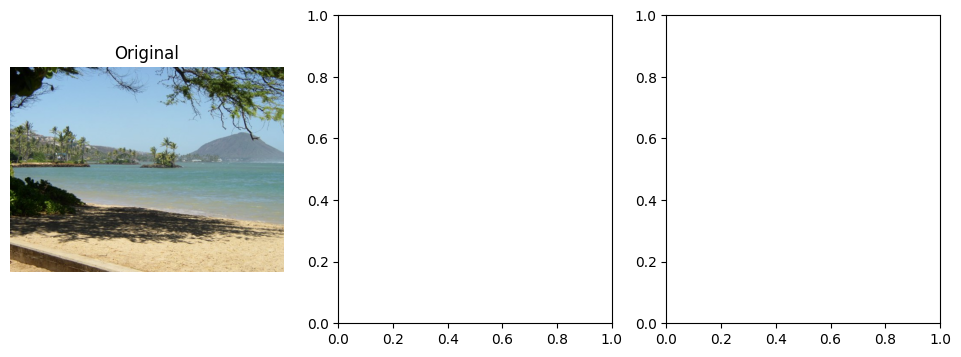

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(transforms.zero_red(pixels)); axes[1].set_title("zero_red"); axes[1].axis("off")
axes[1].imshow(fast_transforms.zero_green(pixels)); axes[1].set_title("zero_green"); axes[1].axis("off")
axes[2].imshow(transforms.mirror_horizontal(pixels)); axes[2].set_title("mirror_horizontal"); axes[2].axis("off")
plt.tight_layout()
plt.show()

## Section 6 - Mirroring an image
Here we will be exploring what an image filter is by copying pixels over from another part of the image.

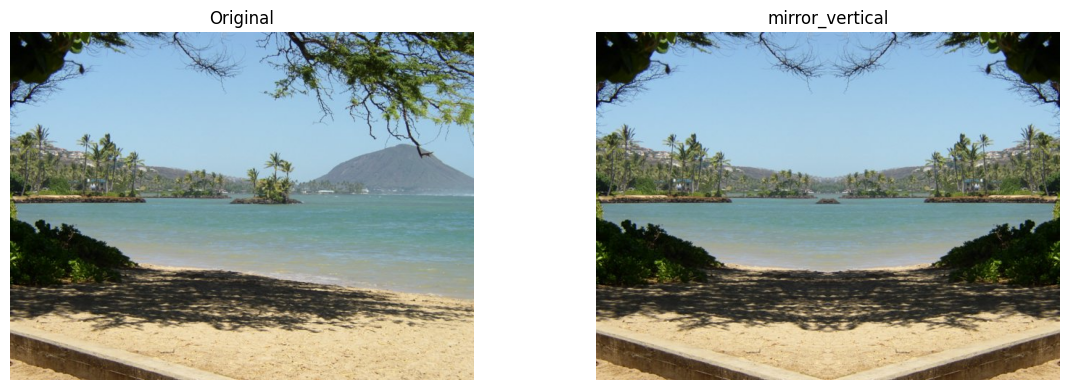

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(transforms.mirror_vertical(pixels)); axes[1].set_title("mirror_vertical"); axes[1].axis("off")
plt.tight_layout()
plt.show()


Create the mirror_horizontal function in the transforms.py file to run the below code

AttributeError: module 'piclab.transforms' has no attribute 'mirror_horizontal'

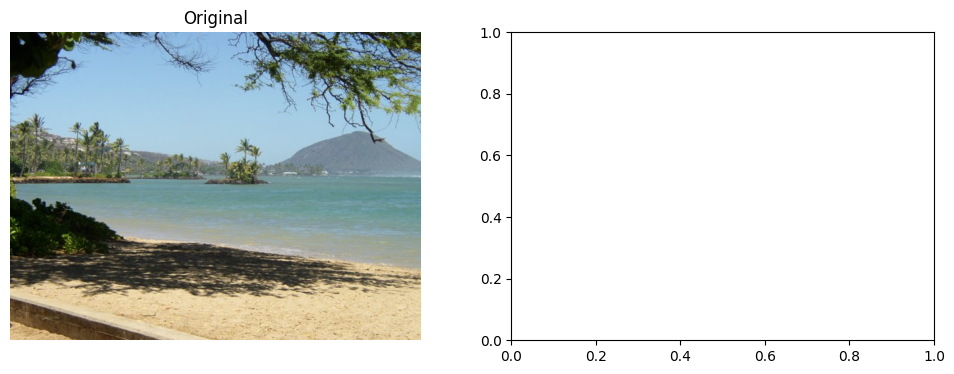

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(transforms.mirror_horizontal(pixels)); axes[1].set_title("mirror_horizontal"); axes[1].axis("off")
plt.tight_layout()
plt.show()

Create the mirror diagonal in the fast transforms file in order to run the following code. You can mirror top-left corner to bottom-right corner, top-right corner to bottom-left corner, or vice versa As long as the image is mirrored over an y = x or a y = -x axis.

AttributeError: module 'piclab.fast_transforms' has no attribute 'mirror_diagonal'

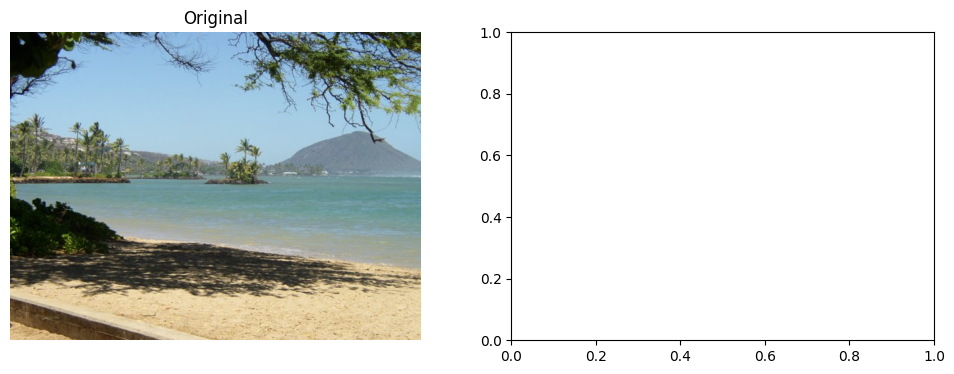

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(fast_transforms.mirror_diagonal(pixels)); axes[1].set_title("mirror_diagonal"); axes[1].axis("off")
plt.tight_layout()
plt.show()

Using either the fast_transforms or the transforms file, create a function that will make the image greyscale. First think about what does it mean for an image to be greyscale? How can you accomplish this and not make the whole image one color? Do not use AI on this particular algorithm until you have discussed it with people in the class or myself.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow("put greyscale function call here"(pixels)); axes[1].set_title("mirror_diagonal"); axes[1].axis("off")
plt.tight_layout()
plt.show()

<>:3: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
<>:3: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?


NameError: name 'plt' is not defined

## Section 7 - Edge detection, with a live threshold slider

`edge_dist` is how different two neighboring pixels' colors have to be
before we call it an edge. Drag it and watch which edges appear or
disappear.

In [ ]:
def show_edges(edge_dist):
    result = fast_transforms.edge_detection(pixels, edge_dist)
    plt.figure(figsize=(5, 4))
    plt.imshow(result)
    plt.axis("off")
    plt.title(f"edge_dist = {edge_dist}")
    plt.show()

interact(show_edges, edge_dist=widgets.IntSlider(min=0, max=200, step=5, value=20));

interactive(children=(IntSlider(value=20, description='edge_dist', max=200, step=5), Output()), _dom_classes=(…

## Step 8 - Chaining Filters
So far, you've applied one filter at a time to the original image. But real filters — the ones on your phone or in social media apps — are almost never just one operation. They're usually several filters applied one after another, each one working on the result of the last one, not on the original picture. This is called chaining.
To chain filters in code, you take the output of one function and feed it in as the input to the next one, instead of always starting from pixels:

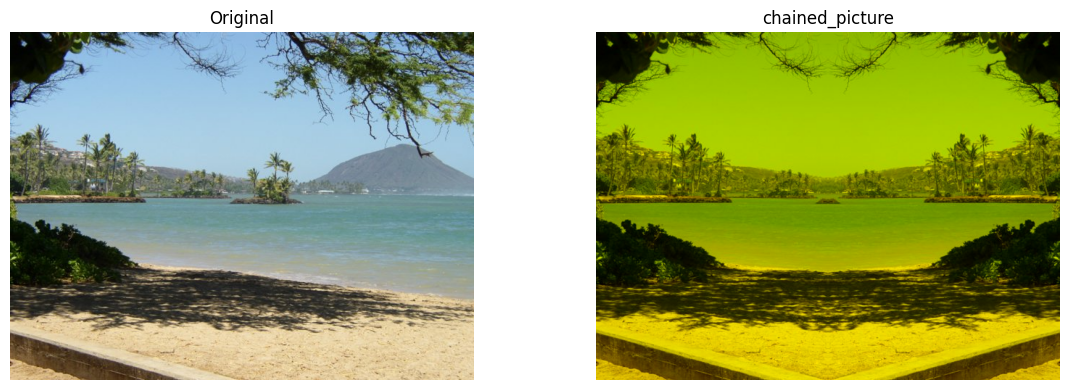

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
step1 = transforms.zero_blue(pixels)
step2 = fast_transforms.mirror_vertical(step1)
axes[1].imshow(step2); axes[1].set_title("chained_picture"); axes[1].axis("off")
plt.tight_layout()
plt.show()



You will be asked in your directions to run the steps in certian orders. Feel free to modify the code below to match the steps. You can either create a new code boxes for each task or just modify the codebox below and change/add steps.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(pixels); axes[0].set_title("Original"); axes[0].axis("off")
step1 = transforms.zero_blue(pixels)
step2 = fast_transforms.mirror_vertical(step1)
axes[1].imshow(step2); axes[1].set_title("chained_picture"); axes[1].axis("off")
plt.tight_layout()
plt.show()